In [1]:
import cv2
import os
import numpy as np
from PIL import Image  # Untuk menangani file yang tidak terbaca oleh OpenCV

# Path folder dataset
folder = r'E:\Project Besar\DS-2'

# Memeriksa apakah folder ada
if not os.path.exists(folder):
    print(f"Folder {folder} tidak ditemukan!")
    exit()

# Membaca file gambar (termasuk .jpg dan .png)
image_files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]

# Menampilkan jumlah file yang ditemukan
print(f'Jumlah file gambar yang ditemukan: {len(image_files)}')

X = []  # Data gambar
y = []  # Label gambar

# Membaca dan memproses setiap gambar
for filename in image_files:
    image_path = os.path.join(folder, filename)

    # Coba membaca gambar dengan OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Jika gambar tidak dapat dibaca oleh OpenCV, gunakan Pillow sebagai cadangan
    if img is None:
        try:
            img_pillow = Image.open(image_path).convert('L')  # Konversi ke grayscale
            img = np.array(img_pillow)  # Konversi gambar ke array NumPy
            print(f"Gambar berhasil dimuat dengan Pillow: {filename}")
        except Exception as e:
            print(f"Gambar tidak dapat dimuat: {filename}, Error: {e}")
            continue

    # Resize gambar menjadi 64x64
    img_resized = cv2.resize(img, (128, 128))
    X.append(img_resized)

    # Ambil label dari nama file (misalnya, angka sebelum underscore "_")
    try:
        label = int(filename.split('_')[0])
        y.append(label)
    except ValueError:
        print(f"Format nama file tidak sesuai: {filename}")
        continue

# Konversi data dan label menjadi array NumPy
X = np.array(X)
y = np.array(y)

print(f"Jumlah gambar yang diproses: {len(X)}")
print(f"Jumlah label yang diproses: {len(y)}")

Jumlah file gambar yang ditemukan: 8550
Gambar berhasil dimuat dengan Pillow: 6_C_6301102009010_2_6.jpg
Jumlah gambar yang diproses: 8550
Jumlah label yang diproses: 8550


fitur ekstrasi HOG

In [2]:
from skimage.feature import hog

# Menambahkan ekstraksi fitur HOG
ekstrasi = []
for img in X:
    # Ekstraksi fitur HOG dari gambar (tanpa parameter 'multichannel')
    fd, hog_image = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    # Menambahkan fitur HOG ke dalam list
    ekstrasi.append(fd)

# Mengubah fitur HOG menjadi numpy array
ekstrasi = np.array(ekstrasi)

# Sekarang, X mengandung fitur HOG, bukan gambar asli
print(f"Dimensi fitur HOG: {ekstrasi.shape}")

Dimensi fitur HOG: (8550, 8100)


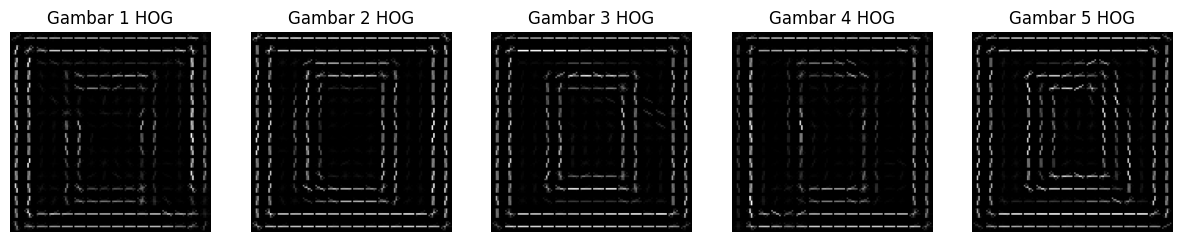

In [3]:
import matplotlib.pyplot as plt

# Menampilkan beberapa hasil gambar HOG
num_samples = 5  # Misalnya, hanya ingin menampilkan 5 gambar
fig, axs = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    # Menggunakan hasil visualisasi hog_image untuk ditampilkan
    fd, hog_image = hog(X[i], pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

    axs[i].imshow(hog_image, cmap='gray')
    axs[i].set_title(f"Gambar {i+1} HOG")
    axs[i].axis('off')

plt.show()

fitur ekstrasi PCA

In [2]:
from sklearn.decomposition import PCA

# Inisialisasi list untuk menyimpan fitur PCA
ekstrasi = []
# Iterasi setiap gambar untuk PCA
for img in X:
    # Meratakan gambar menjadi vektor 1D
    img_flattened = img.flatten()  # Ubah dimensi (128, 128) menjadi (16384,)
    ekstrasi.append(img_flattened)

# Mengubah list menjadi array NumPy
ekstrasi = np.array(ekstrasi)
# Inisialisasi PCA
pca = PCA(n_components=0.95, random_state=42)  # Menjaga 95% variansi
ekstrasi_pca = pca.fit_transform(ekstrasi)

# Menyimpan dimensi fitur hasil PCA
print(f"Dimensi fitur setelah PCA: {ekstrasi_pca.shape}")

Dimensi fitur setelah PCA: (8550, 88)


algoritma SVM

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Menyimpan hasil akurasi untuk berbagai proporsi
split_ratios = [0.4, 0.3, 0.2]  # Test size untuk 60:40, 70:30, 80:20
results = []

for test_size in split_ratios:
    # Membagi data sesuai dengan test_size
    X_train, X_test, y_train, y_test = train_test_split(ekstrasi, y, test_size=test_size, random_state=42)
    
    # Normalisasi fitur
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Melatih model SVM
    clf = SVC(kernel='linear')
    clf.fit(X_train, y_train)
    
    # Memprediksi data uji
    y_pred = clf.predict(X_test)
    
    # Menghitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    results.append((1 - test_size, test_size, accuracy))
    
    # Menampilkan hasil untuk setiap proporsi
    print(f"Proporsi Latih: {1 - test_size:.2f}, Uji: {test_size:.2f}")
    print(f"**Akurasi model {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Menampilkan hasil akhir
print("Hasil Akurasi untuk Proporsi Berbeda:")
for train_ratio, test_ratio, accuracy in results:
    print(f"Latih: {train_ratio:.2f}, Uji: {test_ratio:.2f}, Akurasi model {accuracy * 100:.2f}%")
    

Proporsi Latih: 0.60, Uji: 0.40
**Akurasi model 97.43%
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       420
           1       0.96      0.99      0.98       477
           2       0.99      0.98      0.99       405
           3       0.95      0.98      0.96       342
           4       0.99      0.96      0.97       347
           5       0.98      0.97      0.98       330
           6       0.97      0.97      0.97       300
           7       0.98      0.97      0.97       273
           8       0.98      0.95      0.97       273
           9       0.96      0.96      0.96       253

    accuracy                           0.97      3420
   macro avg       0.97      0.97      0.97      3420
weighted avg       0.97      0.97      0.97      3420

--------------------------------------------------
Proporsi Latih: 0.70, Uji: 0.30
**Akurasi model 97.50%
              precision    recall  f1-score   support

           0       0.97  

algoritma KNN

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Menyimpan hasil akurasi untuk berbagai proporsi
split_ratios = [0.4, 0.3, 0.2]  # Test size untuk 60:40, 70:30, 80:20
results = []

for test_size in split_ratios:
    # Membagi data sesuai dengan test_size
    X_train, X_test, y_train, y_test = train_test_split(ekstrasi, y, test_size=test_size, random_state=42)
    
    # Normalisasi fitur
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    

    # Membuat model KNN dengan k=3 (atau sesuai kebutuhan)
    k = 10  # Anda bisa mencoba berbagai nilai k untuk mencari yang terbaik
    knn = KNeighborsClassifier(n_neighbors=k)

    # Melatih model dengan data latih yang sudah dinormalisasi
    knn.fit(X_train, y_train)
    
    # Memprediksi data uji
    y_pred = knn.predict(X_test)
    
    # Menghitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    results.append((1 - test_size, test_size, accuracy))
    
    # Menampilkan hasil untuk setiap proporsi
    print(f"Proporsi Latih: {1 - test_size:.2f}, Uji: {test_size:.2f}")
    print(f"**Akurasi model {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Menampilkan hasil akhir
print("Hasil Akurasi untuk Proporsi Berbeda:")
for train_ratio, test_ratio, accuracy in results:
    print(f"Latih: {train_ratio:.2f}, Uji: {test_ratio:.2f}, Akurasi model {accuracy * 100:.2f}%")
    

Proporsi Latih: 0.60, Uji: 0.40
**Akurasi model 89.74%
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       420
           1       0.83      0.98      0.90       477
           2       0.95      0.92      0.93       405
           3       0.86      0.90      0.88       342
           4       0.94      0.89      0.91       347
           5       0.87      0.88      0.87       330
           6       0.89      0.88      0.88       300
           7       0.92      0.88      0.90       273
           8       0.87      0.86      0.86       273
           9       0.92      0.73      0.81       253

    accuracy                           0.90      3420
   macro avg       0.90      0.89      0.89      3420
weighted avg       0.90      0.90      0.90      3420

--------------------------------------------------
Proporsi Latih: 0.70, Uji: 0.30
**Akurasi model 90.33%
              precision    recall  f1-score   support

           0       0.96  

algoritma Random Forest

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Menyimpan hasil akurasi untuk berbagai proporsi
split_ratios = [0.4, 0.3, 0.2]  # Test size untuk 60:40, 70:30, 80:20
results = []

for test_size in split_ratios:
    # Membagi data sesuai dengan test_size
    X_train, X_test, y_train, y_test = train_test_split(ekstrasi, y, test_size=test_size, random_state=42)
    
    # Normalisasi fitur
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    

    # Membuat model Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Anda dapat menyesuaikan parameter seperti n_estimators


    # Melatih model dengan data latih yang sudah dinormalisasi
    rf.fit(X_train, y_train)
    
    # Memprediksi data uji
    y_pred = rf.predict(X_test)
    
    # Menghitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    results.append((1 - test_size, test_size, accuracy))
    
    # Menampilkan hasil untuk setiap proporsi
    print(f"Proporsi Latih: {1 - test_size:.2f}, Uji: {test_size:.2f}")
    print(f"**Akurasi model {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Menampilkan hasil akhir
print("Hasil Akurasi untuk Proporsi Berbeda:")
for train_ratio, test_ratio, accuracy in results:
    print(f"Latih: {train_ratio:.2f}, Uji: {test_ratio:.2f}, Akurasi model {accuracy * 100:.2f}%")
    

Proporsi Latih: 0.60, Uji: 0.40
**Akurasi model 94.15%
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       420
           1       0.93      0.98      0.95       477
           2       0.94      0.98      0.96       405
           3       0.91      0.95      0.93       342
           4       0.95      0.93      0.94       347
           5       0.96      0.95      0.95       330
           6       0.94      0.95      0.95       300
           7       0.93      0.95      0.94       273
           8       0.96      0.86      0.91       273
           9       0.95      0.84      0.89       253

    accuracy                           0.94      3420
   macro avg       0.94      0.93      0.94      3420
weighted avg       0.94      0.94      0.94      3420

--------------------------------------------------
Proporsi Latih: 0.70, Uji: 0.30
**Akurasi model 94.11%
              precision    recall  f1-score   support

           0       0.96  